In [1]:
import arbor as A
from arbor import units as U
import pandas as pd
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Detailed cable-cell examples

First, we define the morphology, which we will use for both examples.

In [2]:
# Construct an empty segment tree.
from arbor import segment_tree


tree = A.segment_tree()

# The root of the tree has no parent
root = A.mnpos

# The root segment: a cylindrical soma with tag 1
# NOTE: append returns the added segment's id, which we can use to
#       attach the next segments.
soma = tree.append(root, (0.0, 0.0, 0.0, 2.0), (40.0, 0.0, 0.0, 2.0), tag=1)

# Attach the first section of the dendritic tree with tag 3 to the soma
# up to the first fork
dend = tree.append(soma, (40.0, 0.0, 0.0, 0.8), ( 80.0,  0.0, 0.0, 0.8), tag=3)
dend = tree.append(dend, (80.0, 0.0, 0.0, 0.8), (120.0, -5.0, 0.0, 0.8), tag=3)

# Construct the upper part of the first fork
# NOTE: We do not overwrite the parent here, as we need to attach the
#       lower fork later. Instead, we use new names for this branch.
dend_u = tree.append(dend, (120.0, -5.0, 0.0, 0.8), (200.0,  40.0, 0.0, 0.4), tag=3)
dend_u = tree.append(dend_u, (200.0, 40.0, 0.0, 0.4), (260.0,  60.0, 0.0, 0.2), tag=3)

# Construct the lower part of the first fork
dend_l = tree.append(dend, (120.0, -5.0, 0.0, 0.5), (190.0, -30.0, 0.0, 0.5), tag=3)

# Attach another fork to the last segment, ``p``.
# Upper part
dend_lu = tree.append(dend_l, (190.0, -30.0, 0.0, 0.5), (240.0, -70.0, 0.0, 0.2), tag=4)
# Lower part
dend_ll = tree.append(dend_l, (190.0, -30.0, 0.0, 0.5), (230.0, -10.0, 0.0, 0.2), tag=4)
dend_ll = tree.append(dend_ll, (230.0, -10.0, 0.0, 0.2), (360.0, -20.0, 0.0, 0.2), tag=4)

# Construct the axon with tag 2, attaching to the root ``mnpos``, where its
# proximal end will be connected to the proximal end of the soma segment implicitly.
axon = tree.append(root, (0.0, 0.0, 0.0, 2.0), (-70.0, 0.0, 0.0, 0.4), tag=2)
axon = tree.append(axon, (-70.0, 0.0, 0.0, 0.4), (-100.0, 0.0, 0.0, 0.4), tag=2)

print(tree)

<arbor.segment_tree:
(segment_tree (
  (segment 0 (point 0 0 0 2) (point 40 0 0 2) 1)
  (segment 1 (point 40 0 0 0.8) (point 80 0 0 0.8) 3)
  (segment 2 (point 80 0 0 0.8) (point 120 -5 0 0.8) 3)
  (segment 3 (point 120 -5 0 0.8) (point 200 40 0 0.4) 3)
  (segment 4 (point 200 40 0 0.4) (point 260 60 0 0.2) 3)
  (segment 5 (point 120 -5 0 0.5) (point 190 -30 0 0.5) 3)
  (segment 6 (point 190 -30 0 0.5) (point 240 -70 0 0.2) 4)
  (segment 7 (point 190 -30 0 0.5) (point 230 -10 0 0.2) 4)
  (segment 8 (point 230 -10 0 0.2) (point 360 -20 0 0.2) 4)
  (segment 9 (point 0 0 0 2) (point -70 0 0 0.4) 2)
  (segment 10 (point -70 0 0 0.4) (point -100 0 0 0.4) 2))
  (npos 0 1 2 3 2 5 5 7 npos 9))>


In [3]:

# Turn the segment tree into a morphology.
morph = A.morphology(tree);

# Labels

Dictionary used to map Arbor labels to locations in the morphology.

In [4]:
# (2) Create and populate the label dictionary.
labels = A.label_dict(
    {
        # Regions:
        # Add a label for a region that includes the whole morphology
        "all": "(all)",
        # Add a label for the parts of the morphology with radius greater than 1.5 μm.
        "gt_1.5": '(radius-ge (region "all") 1.5)',
        # Join regions "apic" and "gt_1.5"
        "custom": '(join (tag 3) (region "gt_1.5"))',
        # Locsets:
        # Add a labels for the root of the morphology and all the terminal points
        "root": "(root)",
        "terminal": "(terminal)",
        "soma": "(tag 1)",
        "dend": "(join (tag 3) (tag 4))",
        # Add a label for the terminal locations in the "custom" region:
        "custom_terminal": '(restrict-to (locset "terminal") (region "custom"))',
        # # Add a label for the terminal locations in the "axon" region:
        # "axon_terminal": '(restrict-to (locset "terminal") (region "axon"))',
    }
)

# 1. Simple example

### 1.1 -  Decor
The `decor` is used to define cell properties, placement of mechanisms, synapses, gap junctions, record points, etc. 
Properties set here can be overridden in the recipe later, but this is useful for defining the cable cell model which can be used in multiple recipes.

Note that active density mechanisms like `pas` and `hh` are instantiated here using the `paint` decoration, which applies the mechanism to an area.
Point mechanisms are instantiated using the `place` decoration, which applies the mechanism to a single point.

Ion channel properties can be set here, but for this simple example we will load the default values later, in the recipe definition (using `Arbor.neuron_cable_properties`, which contains the default values).

In [5]:
# (3) Create and populate the decor.
decor = (
    A.decor()
    # Paint density mechanisms.
    .paint('"all"', A.density("pas"))
    .paint('"custom"', A.density("hh"))
    # Place stimuli and detectors.
    .place('"root"', A.i_clamp(10 * U.ms, 1 * U.ms, current=2 * U.nA))  # onset time, duration time, current
    .place('"root"', A.i_clamp(30 * U.ms, 1 * U.ms, current=2 * U.nA))
    .place('"root"', A.i_clamp(50 * U.ms, 1 * U.ms, current=2 * U.nA))
    .place('"custom_terminal"', A.threshold_detector(-10 * U.mV), "detector")  
)

# Set discretisation: Soma as one CV, 1um everywhere else
cvp = A.cv_policy('(replace (single (region "soma")) (max-extent 1.0))')

# (4) Create the cell
cell = A.cable_cell(morph, decor, labels, cvp)

IMPORTANT: the last line of the above code block `cell = A.cable_cell(morph, decor, labels, cvp)` constructs our base cable cell model from morphology, decor, labels, and discretization (cv) policy.
`cell` is used to create the recipe in the next code block.

### 1.2 - Recipe
A recipe is basically the fundamental structure of the Arbor network model. 
In our case, it holds the single cell and parameters.
While some parameters were set before in the cell definition, they can be overridden here.
For instance, "default" ion channel parameters were set in decor, which lives in the cell model, but they can be overridden here as it pertains to the calculation we want to do.

If we want to consider a set of simulations for a range of VGIC parameters, we can leave the cell definition as is and just override the ion channel parameters in the recipe.
Note that that would not necessarily require redefining the recipe class, just changing the relevant attributes.

In [6]:
# (5) Create a class that inherits from A.recipe
class single_recipe(A.recipe):
    # (5.1) Define the class constructor
    def __init__(self):
        # The base C++ class constructor must be called first, to ensure that
        # all memory in the C++ class is initialized correctly.
        A.recipe.__init__(self)
        self.properties = A.neuron_cable_properties() # this line sets the default properties for the cell
        # In the second example we will specify properties individually

    # (5.2) Override the num_cells method
    def num_cells(self):
        return 1

    # (5.3) Override the cell_kind method
    def cell_kind(self, _):
        return A.cell_kind.cable

    # (5.4) Override the cell_description method
    def cell_description(self, _):
        return cell

    # (5.5) Override the probes method
    def probes(self, _):
        return [A.cable_probe_membrane_voltage('"custom_terminal"', "Um")]

    # (5.6) Override the global_properties method
    def global_properties(self, _):
        return self.properties


# Instantiate recipe
recipe = single_recipe()

### 1.3 - Simulation
The recipe is used to instatiate the simulation object in the following code block. The `Arbor.simulation` object includes all our model specifications as well as other things relevant to the simulation calculation itself, like sampling of outputs, parallelization options, etc.

In [7]:
# (6) Create a simulation
sim = A.simulation(recipe)

# Instruct the simulation to record the spikes and sample the probe
sim.record(A.spike_recording.all)

handle = sim.sample((0, "Um"), A.regular_schedule(0.02 * U.ms))

# (7) Run the simulation
sim.run(tfinal=100 * U.ms, dt=0.025 * U.ms)

# (8) Print spikes
spikes = sim.spikes()
print(len(spikes), "spikes recorded:")
for (gid, lid), t in spikes:
    print(f" * t={t:.3f}ms gid={gid} lid={lid}")

print(sim.samples(handle))
# (8) Plot the membrane potential
df = pd.concat(
    [
        pd.DataFrame(
            {
                "t/ms": data[:, 0],
                "U/mV": data[:, 1],
                "Location": str(meta),
                "Variable": "voltage",
            }
        )
        for data, meta in sim.samples(handle)
    ],
    ignore_index=True,
)

0 spikes recorded:
[(array([[ 0.00000000e+00, -6.50000000e+01],
       [ 0.00000000e+00, -6.50000000e+01],
       [ 2.50000000e-02, -6.51192554e+01],
       ...,
       [ 9.99250000e+01, -6.78924410e+01],
       [ 9.99500000e+01, -6.78924388e+01],
       [ 9.99750000e+01, -6.78924367e+01]], shape=(5000, 2)), (location 1 1))]


### 1.4 - Results

Since we specified recording of the membrane potential at the root of the cell, we can now plot that result.

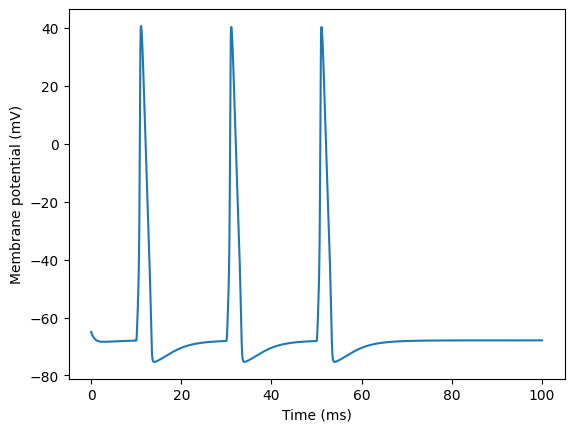

In [8]:
# plot data with matplotlib
plt.plot(df["t/ms"], df["U/mV"])
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.show()

# 2 - More complex example

Now we will create a more complex example, setting individual parameters as we go, still using the same morphology and labels as before.

### 2.1 -  Decor

IMPORTANT: within the `decor`, instatiation of ions and their properties is separate from the instatiation of density mechanisms which define ion dynamics.
For example, below, `set_ion("k", int_con=54.4 * U.mM, ext_con=2.5 * U.mM, rev_pot=-77 * U.mV)` sets the parameters of K ions, but it is the line `paint('"custom"', A.density("hh"))` that makes the K (and Na) dynamics follow the default Hodgkin-Huxley model. 

Parameters (`gbar`, etc.) of the mechanisms (`hh`, `pas`, `Ih`) have default values specified in their `nmodl` file, but can be overridden here within the `paint` function.

We can look up the `nmodl` files in the Arbor Github repository: https://github.com/arbor-sim/arbor/tree/master/mechanisms

As the previous example illustrated, we do not need to speficy ion parameters here if we use the default values in the recipe. The validation for consistency of these things occurs at the simulation level.

In [ ]:
stim_dur = 0.5 * U.ms

# (3) Create and populate the decor.
decor = (
    A.decor()
    # Set the default properties of the cell.
    .set_property(Vm=-55 * U.mV)
    .set_ion(
        "na",
        int_con=10 * U.mM,
        ext_con=140 * U.mM,
        rev_pot=50 * U.mV,
    )
    .set_ion("k", int_con=54.4 * U.mM, ext_con=2.5 * U.mM, rev_pot=-77 * U.mV)
    # Override the cell defaults for individual areas
    .paint('"custom"', tempK=313 * U.Kelvin)
    .paint('"soma"', Vm=-50 * U.mV)
    # Paint density mechanisms.
    .paint('"all"', A.density("pas", {"g": 0.0001}))
    .paint('"custom"', A.density("hh"))
    .paint(
        '"dend"', A.density("Ih", gbar=0.001)
    )  # we didn't have Ih in the previous model. We will need to load the necessary catalogue (mechanisms) in the recipe to use Ih, otherwise it will throw an error.
    # note that mechanism parameters like gbar can be set in the paint() call
    # Place stimuli and detectors.
    .place('"root"', A.i_clamp(10 * U.ms, stim_dur, current=2 * U.nA))
    .place('"root"', A.i_clamp(30 * U.ms, stim_dur, current=2 * U.nA))
    .place('"root"', A.i_clamp(50 * U.ms, stim_dur, current=2 * U.nA))
    .place('"custom_terminal"', A.threshold_detector(-10 * U.mV), "detector")
)

# Set discretisation: Soma as one CV, 1um everywhere else
cvp = A.cv_policy('(replace (single (region "soma")) (max-extent 1.0))')

# (4) Create the cell
cell = A.cable_cell(morph, decor, labels, cvp)

### 2.2 - Recipe

In this recipe, we will set individual ion properties. These will override the values we set above. This functionality exists for convenience, but it is not required. 
We could, for instance, create a list of recipe instances with different parameterizations and run them in parallel, all without changing the cable cell model.

Also, we will set the Ca properties here, even though they were not set explicitly above.

I have added a flag `CONC` (0 or 1) which multiplies the concentrations for Na, K, and Ca, so they can easily be set to zero all at once. The mechanisms `pas`, `hh`, and `Ih` do not use concentrations explicitly, so we will get exactly the same results with them all set to zero. If we were to use a different mechanism which does use concentrations, we would see a difference.

Note that Arbor requires reversal potentials and internal/external concentrations for Na, K, and Ca to be set, even if they are not used explicitly in our active mechanisms. The reason for this is that the majority of mechanisms in their total catalogue (including the Allen Institute and Blue Brain Project) use concentrations explicitly. The developers suggest, in cases where we do not use concentrations explicitly, we can either set them to zero or use the default values, like we did in the previous example.

In [ ]:
CONC = 0 # flag for concentrations: 0 or 1

# (5) Create a class that inherits from A.recipe
class single_recipe(A.recipe):
    # (5.1) Define the class constructor
    def __init__(self):
        # The base C++ class constructor must be called first, to ensure that
        # all memory in the C++ class is initialized correctly.
        A.recipe.__init__(self)

        self.the_props = A.cable_global_properties() # container for global properties

        # we have the option to override global properties here
        self.the_props.set_property(
            Vm=-65 * U.mV,
            tempK=300 * U.Kelvin,
            rL=35.4 * U.Ohm * U.cm,
            cm=0.01 * U.F / U.m2,  # 0.01 F/m^2 = 1.0 uF/cm^2
        )

        # # set passive revpot
        # self.the_props.set_property(
        #     pas_e=-100.0 * U.mV
        # )

        # setting individual ion properties
        # Arbor default values: (https://docs.arbor-sim.org/en/stable/concepts/decor.html)
        # Na: revpot = 50.0 mV, int_conc = 10.0 mM, ext_conc = 140.0 mM
        # K: revpot = -77.0 mV, int_conc = 54.4 mM, ext_conc = 2.5 mM
        # Ca: revpot = 132.458 mV, int_conc = 0.00005 mM, ext_conc = 2 mM
        self.the_props.set_ion(
            ion="na",
            int_con=CONC * 10.0 * U.mM,
            ext_con=CONC * 140.0 * U.mM,
            rev_pot=50 * U.mV,
        )
        self.the_props.set_ion(
            ion="k", 
            int_con=CONC * 54.4 * U.mM, 
            ext_con=CONC * 2.5 * U.mM, 
            rev_pot=-77 * U.mV
        )
        self.the_props.set_ion(
            ion="ca", 
            int_con=CONC * 0.00005 * U.mM, 
            ext_con=CONC * 2 * U.mM, 
            rev_pot=132.5 * U.mV
        )
        self.the_props.catalogue.extend(A.allen_catalogue())  # the Allen catalogue includes the Ih mechanism

    # (5.2) Override the num_cells method
    def num_cells(self):
        return 1

    # (5.3) Override the cell_kind method
    def cell_kind(self, _):
        return A.cell_kind.cable

    # (5.4) Override the cell_description method
    def cell_description(self, _):
        return cell

    # (5.5) Override the probes method
    def probes(self, _):
        return [A.cable_probe_membrane_voltage('"custom_terminal"', "Um")]

    # (5.6) Override the global_properties method
    def global_properties(self, _):
        return self.the_props


# Instantiate recipe
recipe = single_recipe()

### 2.3 - Simulation

In [16]:
# (6) Create a simulation
sim = A.simulation(recipe)

# Instruct the simulation to record the spikes and sample the probe
sim.record(A.spike_recording.all)

handle = sim.sample((0, "Um"), A.regular_schedule(0.02 * U.ms))

# (7) Run the simulation
sim.run(tfinal=100 * U.ms, dt=0.025 * U.ms)

# (8) Print spikes
spikes = sim.spikes()
print(len(spikes), "spikes recorded:")
for (gid, lid), t in spikes:
    print(f" * t={t:.3f}ms gid={gid} lid={lid}")

print(sim.samples(handle))
# (8) Plot the membrane potential
df = pd.concat(
    [
        pd.DataFrame(
            {
                "t/ms": data[:, 0],
                "U/mV": data[:, 1],
                "Location": str(meta),
                "Variable": "voltage",
            }
        )
        for data, meta in sim.samples(handle)
    ],
    ignore_index=True,
)

TypeError: 'arbor._arbor.cable_global_properties' object does not support item assignment

### 2.4 - Results

Since we specified recording of the membrane potential at the root of the cell, we can now plot that result.

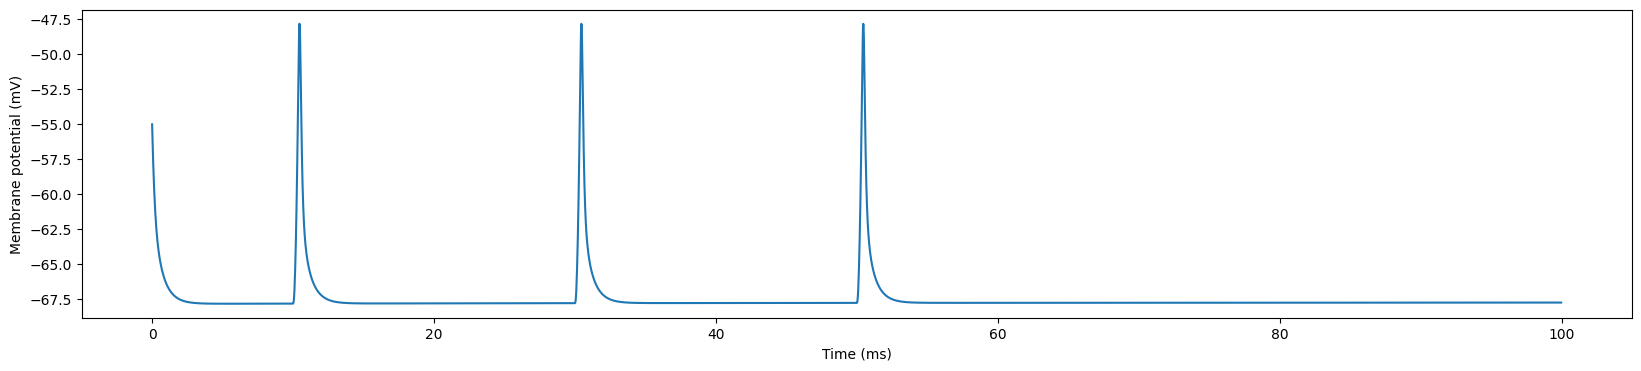

In [ ]:
# plot data with matplotlib
plt.figure(figsize=(20,4))
plt.plot(df["t/ms"], df["U/mV"])
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.show()